In [1]:
!pip install catboost
import catboost

In [2]:
!pip install pytorch-tabnet

In [3]:
!pip install lightgbm
import lightgbm

In [4]:
!pip install xgboost

In [5]:
!pip install catboost
from catboost import CatBoostRegressor

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,roc_auc_score
from lightgbm import LGBMRegressor


In [7]:
from sklearn.ensemble import RandomForestRegressor


In [8]:
import pandas as pd

df = pd.read_csv('merged_data.csv')
df.head()

,stitch_id_flat,umls_id_se,concept_type,side_effect_name,meddra_type,umls_id2,indication_name,drug_name
0,CID100000085,C0000729,LLT,Abdominal cramps,LLT,C0015544,Failure to thrive,carnitine
1,CID100000085,C0000729,LLT,Abdominal cramps,PT,C0015544,Failure to thrive,carnitine
2,CID100000085,C0000729,LLT,Abdominal cramps,LLT,C0020615,Hypoglycaemia,carnitine
3,CID100000085,C0000729,LLT,Abdominal cramps,PT,C0020615,Hypoglycaemia,carnitine
4,CID100000085,C0000729,LLT,Abdominal cramps,LLT,C0022661,Renal failure chronic,carnitine


In [9]:
# Step 1: Identify rare and common side effects
side_effect_counts = df['side_effect_name'].value_counts()
rare_side_effects = side_effect_counts[side_effect_counts < 1550].index  # Adjust threshold as needed
common_side_effects = side_effect_counts[side_effect_counts >= 1550].index

# Step 2: Keep all rare side effect records, sample common ones
rare_df = df[df['side_effect_name'].isin(rare_side_effects)]
common_df = df[df['side_effect_name'].isin(common_side_effects)].groupby('side_effect_name').sample(frac=0.1, random_state=42)

# Step 3: Combine datasets
downsampled_df = pd.concat([rare_df, common_df])

# Step 4: Shuffle the final dataset
downsampled_df = downsampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset reduced from {len(df)} to {len(downsampled_df)} records.")

Dataset reduced from 9312040 to 2071000 records.


In [10]:
print(downsampled_df.columns.tolist())

['stitch_id_flat', 'umls_id_se', 'concept_type', 'side_effect_name', 'meddra_type', 'umls_id2', 'indication_name', 'drug_name']


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocess text columns
downsampled_df['side_effect_name'] = downsampled_df['side_effect_name'].fillna("").str.lower()
downsampled_df['indication_name'] = downsampled_df['indication_name'].fillna("").str.lower()

# Apply TF-IDF
vectorizer_se = TfidfVectorizer(max_features=50)
side_effect_tfidf = vectorizer_se.fit_transform(downsampled_df['side_effect_name']).toarray()

vectorizer_ind = TfidfVectorizer(max_features=50)
indication_tfidf = vectorizer_ind.fit_transform(downsampled_df['indication_name']).toarray()

# Convert to DataFrame
se_tfidf_df = pd.DataFrame(side_effect_tfidf, columns=[f'se_tfidf_{i}' for i in range(50)])
ind_tfidf_df = pd.DataFrame(indication_tfidf, columns=[f'ind_tfidf_{i}' for i in range(50)])

# Concatenate
downsampled_df = pd.concat([downsampled_df, se_tfidf_df, ind_tfidf_df], axis=1)

downsampled_df.head()

,stitch_id_flat,umls_id_se,concept_type,side_effect_name,meddra_type,umls_id2,indication_name,drug_name,se_tfidf_0,se_tfidf_1,...,ind_tfidf_40,ind_tfidf_41,ind_tfidf_42,ind_tfidf_43,ind_tfidf_44,ind_tfidf_45,ind_tfidf_46,ind_tfidf_47,ind_tfidf_48,ind_tfidf_49
0,CID124826799,C0007222,PT,cardiovascular disorder,PT,C0020538,hypertension,ponatinib,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CID100003032,C0035078,PT,renal failure,PT,C1611174,post-traumatic pain,diclofenac,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CID100004691,C0917801,LLT,insomnia,LLT,C2242996,tingling sensation,paroxetine,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CID100003403,C0151786,PT,muscular weakness,PT,C0007273,carotid artery disease,fluvastatin,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CID100002478,C0948484,LLT,anal discomfort,LLT,C0023418,leukaemia,busulfan,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
# Calculate side effect frequencies
side_effect_counts = downsampled_df['side_effect_name'].value_counts().to_dict()
downsampled_df['side_effect_freq'] = downsampled_df['side_effect_name'].map(side_effect_counts)

# Normalize side effect frequency
downsampled_df['side_effect_freq'] = (downsampled_df['side_effect_freq'] / downsampled_df['side_effect_freq'].max()).clip(0, 1)

In [13]:
# Calculate co-occurrence of indication and side effect
co_occurrence = (
    downsampled_df
    .groupby(['indication_name', 'side_effect_name'])
    .size()
    .reset_index(name='co_occurrence_count')
)

downsampled_df = downsampled_df.merge(
    co_occurrence,
    on=['indication_name', 'side_effect_name'],
    how='left'
)

# Calculate indication frequency
indication_counts = downsampled_df['indication_name'].value_counts().to_dict()
downsampled_df['indication_freq'] = downsampled_df['indication_name'].map(indication_counts)

# Calculate indication-side effect relevance
downsampled_df['indication_side_effect_relevance'] = (
    downsampled_df['co_occurrence_count'] /
    downsampled_df['indication_freq']
).fillna(0).clip(0, 1)

In [14]:
# Calculate drug-side effect co-occurrence
drug_side_effect_co_occurrence = downsampled_df.groupby(['drug_name', 'side_effect_name']).size().reset_index(name='drug_side_effect_count')
downsampled_df = downsampled_df.merge(drug_side_effect_co_occurrence, on=['drug_name', 'side_effect_name'], how='left')

# Calculate total occurrences of each drug
drug_total_counts = downsampled_df.groupby('drug_name').size().reset_index(name='drug_total_count')
downsampled_df = downsampled_df.merge(drug_total_counts, on='drug_name', how='left')

# Calculate drug-side effect relevance
downsampled_df['drug_side_effect_relevance'] = (downsampled_df['drug_side_effect_count'] / downsampled_df['drug_total_count']).fillna(0).clip(0, 1)

In [15]:
# One-hot encode drug names
drug_name_ohe = pd.get_dummies(downsampled_df['drug_name'], prefix='drug')
downsampled_df = pd.concat([downsampled_df, drug_name_ohe], axis=1)
import joblib

dummy_columns = drug_name_ohe.columns.tolist()
joblib.dump(dummy_columns, "drug_dummy_columns.pkl")

print("✅ Dummy column names saved")

✅ Dummy column names saved


In [16]:
downsampled_df['adverse_reaction_probability'] = (
    0.5 * downsampled_df['side_effect_freq'] +
    0.3 * downsampled_df['indication_side_effect_relevance'] +
    0.2 * downsampled_df['drug_side_effect_relevance']
).clip(0, 1)

In [17]:
downsampled_df['adverse_reaction_probability'].describe()

count    2.071000e+06
mean     8.692213e-02
std      8.249859e-02
min      5.221746e-04
25%      3.180465e-02
50%      6.336333e-02
75%      1.057599e-01
max      8.814815e-01
Name: adverse_reaction_probability, dtype: float64

In [18]:
downsampled_df.drop(
    columns=[
        'side_effect_freq',
        'indication_side_effect_relevance',
        'drug_side_effect_relevance'
    ],
    errors='ignore',
    inplace=True
)

downsampled_df.drop(
    columns=[
        'stitch_id_flat',
        'umls_id_se',
        'concept_type',
        'side_effect_name',
        'meddra_type',
        'umls_id2',
        'indication_name',   # ← corrected
        'drug_name'
    ],
    errors='ignore',   # prevents crash
    inplace=True
)

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define feature and target columns
feature_cols = [col for col in downsampled_df.columns if col != 'adverse_reaction_probability']
X = downsampled_df[feature_cols]
y = downsampled_df['adverse_reaction_probability']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
import joblib

# 🔥 SAVE FULL FEATURE COLUMN ORDER
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

print("✅ feature_columns.pkl saved")

✅ feature_columns.pkl saved


In [21]:
from lightgbm import LGBMRegressor
lgbm = LGBMRegressor(
    n_estimators=100,
    reg_lambda=0.1,

    min_child_samples=20,
    random_state=42,
    max_depth=5
)

In [22]:
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.636050 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 1449700, number of used features: 1307
[LightGBM] [Info] Start training from score 0.086885
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [23]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict
lgm_pred = lgbm.predict(X_test)

# Evaluate
print("Mean Squared Error:", mean_squared_error(y_test, lgm_pred))
print("R² Score:", r2_score(y_test, lgm_pred))

/Users/srinadh/Downloads/Adverse Drug Reactions copy/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Mean Squared Error: 0.0037065001345302187
R² Score: 0.4562420172743611


In [24]:
from xgboost import XGBRegressor

In [25]:
xgbregressor=XGBRegressor(n_estimators=30,
                          max_depth=5,
                          random_state=42,

                          n_jobs=-1,
                          reg_lambda=0.2,
                         reg_alpha=0.1,)


In [26]:
xgbregressor.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [27]:
xgb_pred=xgbregressor.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, xgb_pred))
print("R-Squared Score:", r2_score(y_test, xgb_pred))

Mean Squared Error: 0.0037449630383215742
R-Squared Score: 0.4505993597224254


In [28]:
from catboost import CatBoostRegressor
catboost_model= CatBoostRegressor(n_estimators=600)

In [29]:
catboost_model.fit(X_train,y_train)

Learning rate set to 0.195896
0:	learn: 0.0785347	total: 105ms	remaining: 1m 2s
1:	learn: 0.0756835	total: 137ms	remaining: 41s
2:	learn: 0.0733793	total: 175ms	remaining: 34.8s
3:	learn: 0.0715798	total: 207ms	remaining: 30.9s
4:	learn: 0.0703961	total: 238ms	remaining: 28.4s
5:	learn: 0.0693844	total: 269ms	remaining: 26.6s
6:	learn: 0.0684974	total: 300ms	remaining: 25.5s
7:	learn: 0.0677593	total: 332ms	remaining: 24.6s
8:	learn: 0.0672864	total: 364ms	remaining: 23.9s
9:	learn: 0.0668547	total: 396ms	remaining: 23.4s
10:	learn: 0.0665416	total: 423ms	remaining: 22.6s
11:	learn: 0.0661752	total: 457ms	remaining: 22.4s
12:	learn: 0.0658750	total: 493ms	remaining: 22.3s
13:	learn: 0.0655229	total: 527ms	remaining: 22s
14:	learn: 0.0653410	total: 552ms	remaining: 21.5s
15:	learn: 0.0651177	total: 579ms	remaining: 21.1s
16:	learn: 0.0648700	total: 614ms	remaining: 21s
17:	learn: 0.0646896	total: 642ms	remaining: 20.7s
18:	learn: 0.0645455	total: 670ms	remaining: 20.5s
19:	learn: 0.0644

CatBoostRegressor(loss_function='RMSE', n_estimators=600)

In [30]:
catboost_pred=catboost_model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, catboost_pred))
print("R-Squared Score:", r2_score(y_test, catboost_pred))

Mean Squared Error: 0.0031533114908430904
R-Squared Score: 0.5373969424167475


In [31]:
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [33]:
#get the predictions again
xgb_pred=xgbregressor.predict(X_test)
lgbm_pred=lgbm.predict(X_test)
cat_pred=catboost_model.predict(X_test)


/Users/srinadh/Downloads/Adverse Drug Reactions copy/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [34]:
import numpy as np
stacked_predictions= np.column_stack((xgb_pred,lgbm_pred,cat_pred))

In [35]:
from sklearn.ensemble import RandomForestRegressor
meta_model = RandomForestRegressor(n_estimators=30, n_jobs=-1)

In [36]:
meta_model.fit(stacked_predictions,y_test)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [37]:
meta_model_pred=meta_model.predict(stacked_predictions)

In [38]:
import joblib

# ✅ Save TF-IDF VECTORIZERS (NOT transformed arrays)
joblib.dump(vectorizer_se, 'tfidf_side_effect.pkl')
joblib.dump(vectorizer_ind, 'tfidf_indication.pkl')

# ✅ Save OneHotEncoder (NOT encoded matrix)
joblib.dump(drug_name_ohe, 'onehot_drug.pkl')

# ✅ Save StandardScaler
joblib.dump(scaler, 'scaler.pkl')

print("✅ Preprocessing objects saved correctly")

✅ Preprocessing objects saved correctly


In [39]:
import joblib

In [40]:
joblib.dump(lgbm, 'adr_lightgbm_model.pkl')
joblib.dump(xgbregressor, 'adr_xgboost_model.pkl')
joblib.dump(catboost_model, 'adr_catboost_model.pkl')

print("✅ Base models saved correctly")

✅ Base models saved correctly


In [41]:
joblib.dump(meta_model, 'adr_meta_model.pkl')

print("✅ Meta model saved correctly")

✅ Meta model saved correctly


#Evaluations

In [42]:
lgbm_pred=lgbm.predict(X_test)
xgb_pred=xgbregressor.predict(X_test)
cat_pred=catboost_model.predict(X_test)
meta_model_pred=meta_model.predict(np.column_stack((xgb_pred,lgbm_pred,cat_pred)))

/Users/srinadh/Downloads/Adverse Drug Reactions copy/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [43]:
print("LGB Mean Squared Error:  ",mean_squared_error(y_test, lgbm_pred))
print("XGB Mean Squared Error:  ",mean_squared_error(y_test, xgb_pred))
print("Cat Mean Squared Error:  ",mean_squared_error(y_test, cat_pred))
print("Meta model Mean Squared Error:  ",mean_squared_error(y_test, meta_model_pred))

LGB Mean Squared Error:   0.0037065001345302187
XGB Mean Squared Error:   0.0037449630383215742
Cat Mean Squared Error:   0.0031533114908430904
Meta model Mean Squared Error:   0.0008258930350719134


In [44]:
print("LGB R-Squared Score:  ",r2_score(y_test, lgbm_pred))
print("XGB R-Squared Score:  ",r2_score(y_test, xgb_pred))
print("Cat R-Squared Score:  ",r2_score(y_test, cat_pred))
print("Meta model R-Squared Score:  ",r2_score(y_test, meta_model_pred))

LGB R-Squared Score:   0.4562420172743611
XGB R-Squared Score:   0.4505993597224254
Cat R-Squared Score:   0.5373969424167475
Meta model R-Squared Score:   0.8788382802109952


In [45]:
from sklearn.metrics import mean_absolute_error
print("LGB MAE: ",mean_absolute_error(y_test, lgbm_pred))
print("XGB MAE: ",mean_absolute_error(y_test, xgb_pred))
print("Cat MAE: ",mean_absolute_error(y_test, cat_pred))
print("Meta model MAE: ",mean_absolute_error(y_test, meta_model_pred))

LGB MAE:  0.041977417858119016
XGB MAE:  0.04224062074726993
Cat MAE:  0.038656808243481666
Meta model MAE:  0.018322026146678657


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

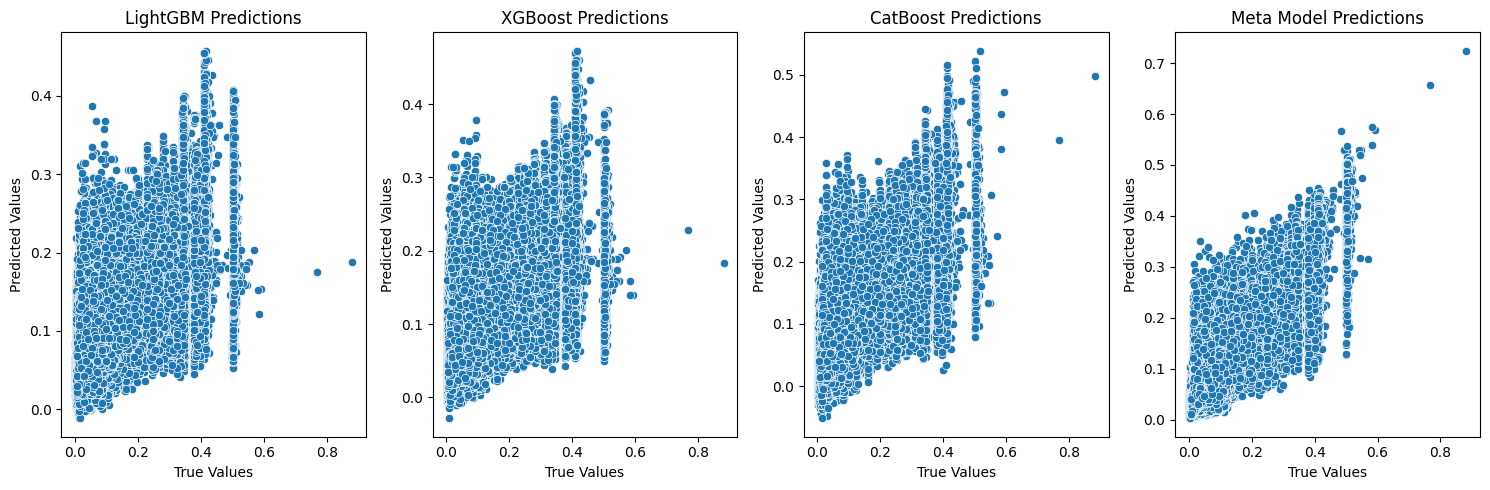

In [47]:
plt.figure(figsize=(15, 5))
# LightGBM
plt.subplot(1, 4, 1)
sns.scatterplot(x=y_test, y=lgbm_pred)
plt.title("LightGBM Predictions")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.subplot(1, 4, 2)
sns.scatterplot(x=y_test, y=xgb_pred)
plt.title("XGBoost Predictions")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.subplot(1, 4, 3)
sns.scatterplot(x=y_test, y=cat_pred)
plt.title("CatBoost Predictions")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.subplot(1, 4, 4)
sns.scatterplot(x=y_test, y=meta_model_pred)
plt.title("Meta Model Predictions")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.tight_layout()
plt.show()

In [48]:
print(y.describe())

count    2.071000e+06
mean     8.692213e-02
std      8.249859e-02
min      5.221746e-04
25%      3.180465e-02
50%      6.336333e-02
75%      1.057599e-01
max      8.814815e-01
Name: adverse_reaction_probability, dtype: float64


In [49]:
import pandas as pd

# Load full dataset
df = pd.read_csv("merged_data.csv")

print("Original shape:", df.shape)

# Strategy: sample max 100 rows per drug
sample_list = []

for drug in df['drug_name'].unique():
    drug_data = df[df['drug_name'] == drug]
    sample_list.append(drug_data.sample(
        n=min(100, len(drug_data)),
        random_state=42
    ))

sample_df = pd.concat(sample_list)

print("Sample shape:", sample_df.shape)

# Save sample file
sample_df.to_csv("sample_data.csv", index=False)

print("✅ sample_data.csv created successfully")

Original shape: (9312040, 8)
Sample shape: (125369, 8)
✅ sample_data.csv created successfully


In [50]:
import joblib

obj = joblib.load("tfidf_indication.pkl")
print(type(obj))

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [51]:
downsampled_df['adverse_reaction_probability'].describe()

count    2.071000e+06
mean     8.692213e-02
std      8.249859e-02
min      5.221746e-04
25%      3.180465e-02
50%      6.336333e-02
75%      1.057599e-01
max      8.814815e-01
Name: adverse_reaction_probability, dtype: float64

In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [53]:
def print_metrics(name, y_true, y_pred):
    print(f"\n{name} Metrics:")
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:   ", recall_score(y_true, y_pred))
    print("F1 Score: ", f1_score(y_true, y_pred))


print_metrics("LightGBM", y_test_class, lgbm_class)
print_metrics("XGBoost", y_test_class, xgb_class)
print_metrics("CatBoost", y_test_class, cat_class)
print_metrics("Meta Model", y_test_class, meta_class)

NameError: name 'y_test_class' is not defined